In [1]:
.libPaths()

[1] "/home/mehwish/miniconda3/envs/cancer-bioinfo/lib/R/library"

In [2]:
R.version.string

[1] "R version 4.3.3 (2024-02-29)"

In [3]:
library(clusterProfiler)



clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




In [4]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(data.table)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vectors

In [5]:
gene_symbols <- genes$gene_name

gene_ids <- bitr(
  gene_symbols,
  fromType = "SYMBOL",
  toType = "ENTREZID",
  OrgDb = org.Hs.eg.db
)

head(gene_ids)

ERROR: Error: object 'genes' not found


In [6]:
library(data.table)

In [7]:
genes <- fread(
  "data/processed/significant_genes_TCGA_LUAD.csv"
)

ERROR: Error in fread("data/processed/significant_genes_TCGA_LUAD.csv"): File 'data/processed/significant_genes_TCGA_LUAD.csv' does not exist or is non-readable. getwd()=='/mnt/d/Cancer_Biomarker_Project/notebooks'


In [8]:
setwd("/mnt/d/Cancer_Biomarker_Project")

In [13]:
getwd()

[1] "/mnt/d/Cancer_Biomarker_Project"

In [9]:
genes <- fread(
  "data/processed/significant_genes_TCGA_LUAD.csv"
)

head(genes)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000147689.16,6257.3020,6.791700,0.2369153,28.66720,9.785412e-181,4.296774e-176,FAM83A
ENSG00000183010.17,3613.0537,3.687783,0.1328495,27.75910,1.353073e-169,2.970671e-165,PYCR1
ENSG00000165312.6,1098.8338,-2.120458,0.0813114,-26.07824,6.437082e-150,9.421742e-146,OTUD1
ENSG00000272620.2,2784.3456,6.305807,0.2572528,24.51211,1.097382e-132,1.204652e-128,AFAP1-AS1
ENSG00000116016.14,26990.0058,-2.723979,0.1113997,-24.45230,4.757257e-132,4.177823e-128,EPAS1
ENSG00000135604.10,805.3661,-3.067332,0.1258437,-24.37414,3.216347e-131,2.353830e-127,STX11


In [11]:
gene_symbols <- genes$gene_name

In [14]:
gene_ids <- bitr(
  gene_symbols,
  fromType = "SYMBOL",
  toType = "ENTREZID",
  OrgDb = org.Hs.eg.db
)

head(gene_ids)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", :
“35.56% of input gene IDs are fail to map...”


,SYMBOL,ENTREZID
,<chr>,<chr>
1,FAM83A,84985
2,PYCR1,5831
3,OTUD1,220213
4,AFAP1-AS1,84740
5,EPAS1,2034
6,STX11,8676


In [15]:
ego <- enrichGO(
  gene = gene_ids$ENTREZID,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  readable = TRUE
)

In [16]:
ego_results <- as.data.frame(ego)

head(ego_results)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0002377,GO:0002377,immunoglobulin production,105/5065,196/18870,1.637950e-15,1.026995e-11,8.491480e-12,EXO1/POLQ/HLA-E/HSPD1/ATAD5/FOXP3/EPHB2/IL6/IGKV3-15/IGKV4-1/IGLV3-21/SAMHD1/IGKV3D-15/GPI/IGKV1-5/IL33/IGLV1-40/IGKV1D-33/BTK/IGKV3D-11/IGLV2-14/PRKDC/IGKV2-28/IGLV4-69/IGKV1-9/IGKV2D-28/IGLV3-12/IGLV6-57/IGLV3-19/IGLV3-1/IGLV2-8/IGKV1-8/POLB/IGKV3-7/IGLV3-25/MZB1/TRAF2/IGLV1-47/TNFSF13/IGKV1-16/IGKV1-17/IGLV1-50/IGLV2-23/IGKV1-13/IGLV3-9/IGKV1-39/IGKV3-20/IGKV1D-17/IGKV1D-39/IGLV1-44/IGKV3D-20/IGKV2D-29/IGKV1-27/IGLV3-10/IGKV1D-12/IGKV6-21/IGKV3D-7/IGKV1-6/IGKV1D-8/IGLV5-45/VPREB3/IGLV2-33/IGKV1-12/IGLV3-16/TNFSF4/IGKV2-40/IGKV2-30/IGLV2-11/IGKV5-2/IGLV7-43/IGLV4-60/IGKV6D-21/IGLV1-36/IGLV3-27/IGLV2-18/IGLV1-51/IGLV7-46/RBP4/BATF/IGLV5-48/IGKV1D-37/IL13/IGLV5-37/NFKBIZ/IGKV2D-30/TFRC/IGKV1D-43/IGLV8-61/IGKV1-37/IGLV9-49/IL21/IGLV3-32/IGKV2-29/IGKV2-24/IGLV10-54/IGKV1D-13/IGKV2D-24/ZPBP2/IGKV1D-42/IGKV2D-26/HPX/IGKV6D-41/IGLV4-3/IGLV11-55/IGLV3-22,105
GO:0007188,GO:0007188,adenylate cyclase-modulating G protein-coupled receptor signaling pathway,121/5065,248/18870,1.014338e-13,2.628722e-10,2.173500e-10,S1PR1/RAMP3/ADM2/RAMP2/CALCRL/LGR4/GRK5/ADRB2/VIPR1/RXFP1/ADGRF4/ADCY4/ADGRE3/SSTR4/GNAQ/FPR2/RAPGEF4/CHRM1/ADRB1/P2RY1/S1PR4/ADGRL2/ADGRE1/MARCO/PDE2A/CALCA/GPR4/PTH1R/GPER1/ADCYAP1R1/EDN1/PTGIR/PTGER4/INSL3/ADGRL4/FPR1/GPR37/RAMP1/ADRA1A/UCN2/ADGRE5/RIMS2/PTHLH/TSHR/GPR78/ADGRG1/AVPR2/HTR1D/MCHR1/ADCY9/MTNR1A/CHRM2/CALCB/AKAP13/GCGR/GRM4/ADGRB1/ADGRF1/ADGRB2/TBXA2R/ADRA1D/OPRD1/GPR65/ADGRG7/VIP/ADCY8/MC4R/S1PR5/RXFP2/GRM3/GIP/PF4/CNR1/PALM/LHCGR/GALR2/GABBR2/CCR3/MC5R/ADGRB3/ADGRD1/APLP1/ADGRD2/ADGRF5/CORT/GPR37L1/ADGRG4/CALCR/PTGDR2/P2RY12/CXCL9/ADRA2A/ITGB3/PTH2R/OPRK1/GALR3/ADGRL3/OPRM1/CNR2/PTGFR/CHRM4/ADGRF2/ADORA1/GPR12/GCG/IAPP/FSHR/AKAP12/GPR26/CASR/TCP11/HRH3/GLP2R/CHGA/MC2R/UCN3/GNAT1/GPR101/NPY2R/PTH/HTR1A,121
GO:0045229,GO:0045229,external encapsulating structure organization,148/5065,323/18870,1.311172e-13,2.628722e-10,2.173500e-10,RGCC/RAMP2/COL10A1/MMP11/GREM1/COL11A1/SPOCK2/FOXF1/FERMT1/CAV1/SLC39A8/MMP13/RXFP1/MMP1/TIE1/ADAMTS14/WNT3A/ERO1A/P3H4/ADAMTS8/ADAMTS1/COL17A1/MMP12/TNR/CAV2/COL1A1/MFAP4/RECK/ABI3BP/COL22A1/TGM1/ENG/IBSP/COL3A1/ADAM8/SULF1/ADAMTSL3/FAP/ITGA8/COL7A1/MELTF/GAS6/PRSS2/MMP17/TNXB/GPM6B/COL5A2/MMP3/COL24A1/MMP19/IL6/TLL2/NTN4/FGFR4/HAS1/COL5A1/PRDX4/SMOC1/SERPINB5/PRSS1/FBLN5/COMP/ADAMTSL4/ANGPTL7/GFAP/LAMB2/ADTRP/ADAMTS12/ADAMTS16/NR2E1/SERPINH1/MMP10/CCN1/PRICKLE1/FKBP10/AGT/NPNT/HPSE2/MYH11/CTSV/VIT/PRDM5/TLL1/BMP2/MMP9/LOXL2/COL9A2/POSTN/PTX3/FBLN1/TPSAB1/ECM2/NDNF/PHLDB2/NOX1/COL1A2/ADAMTS20/PDPN/COL9A3/SCX/MMP14/C6orf15/COL13A1/LCP1/ADAMTS15/ADAMTSL5/COL2A1/OLFML2A/TMPRSS6/DDR2/DPT/MATN3/MMP7/CPB2/WDR72/CARMIL2/FOXF2/COL9A1/CTSG/LOXL1/DMP1/THSD4/MMP15/CMA1/COL4A4/COL4A3/ADAMTS18/ADAMTS4/NPHS1/COL11A2/APLP1/SOX9/DPP4/MMP16/MMP8/SFRP2/TGFB2/ITGB3/HPN/COL28A1/MMP20/SPINK5/COLGALT2/MMP28/MIA/COL19A1/IHH/OPTC,148
GO:0030198,GO:0030198,extracellular matrix organization,147/5065,321/18870,1.677015e-13,2.628722e-10,2.173500e-10,RGCC/RAMP2/COL10A1/MMP11/GREM1/COL11A1/SPOCK2/FOXF1/FERMT1/CAV1/SLC39A8/MMP13/RXFP1/MMP1/TIE1/ADAMTS14/WNT3A/ERO1A/P3H4/ADAMTS8/ADAMTS1/COL17A1/MMP12/TNR/CAV2/COL1A1/MFAP4/RECK/ABI3BP/COL22A1/ENG/IBSP/COL3A1/ADAM8/SULF1/ADAMTSL3/FAP/ITGA8/COL7A1/MELTF/GAS6/PRSS2/MMP17/TNXB/GPM6B/COL5A2/MMP3/COL24A1/MMP19/IL6/TLL2/NTN4/FGFR4/HAS1/COL5A1/PRDX4/SMOC1/SERPINB5/PRSS1/FBLN5/COMP/ADAMTSL4/ANGPTL7/GFAP/LAMB2/ADTRP/ADAMTS12/ADAMTS16/NR2E1/SERPINH1/MMP10/CCN1/PRICKLE1/FKBP10/AGT/NPNT/HPSE2/MYH11/CTSV/VIT/PRDM5/TLL1/BMP2/MMP9/LOXL2/COL9A2/POSTN/PTX3/FBLN1/TPSAB1/ECM2/NDNF/PHLDB2/NOX1/COL1A2/ADAMTS20/PDPN/COL9A3/SCX/MMP14/C6orf15/COL13A1/LCP1/ADAMTS15/ADAMTSL5/COL2A1/OLFML2A/TMPRSS6/DDR2/DPT/MATN3/MMP7/CPB2/WDR72/CARMIL2/FOXF2/COL9A1/CTSG/LOXL1/DMP1/THSD4/MMP15/CMA1/COL4A4/COL4A3/ADAMTS18/ADAMTS4/NPHS1/COL11A2/APLP1/SOX9/DPP4/MMP16/MMP8/SFRP2/TGFB2/ITG

In [17]:
nrow(ego_results)

[1] 635

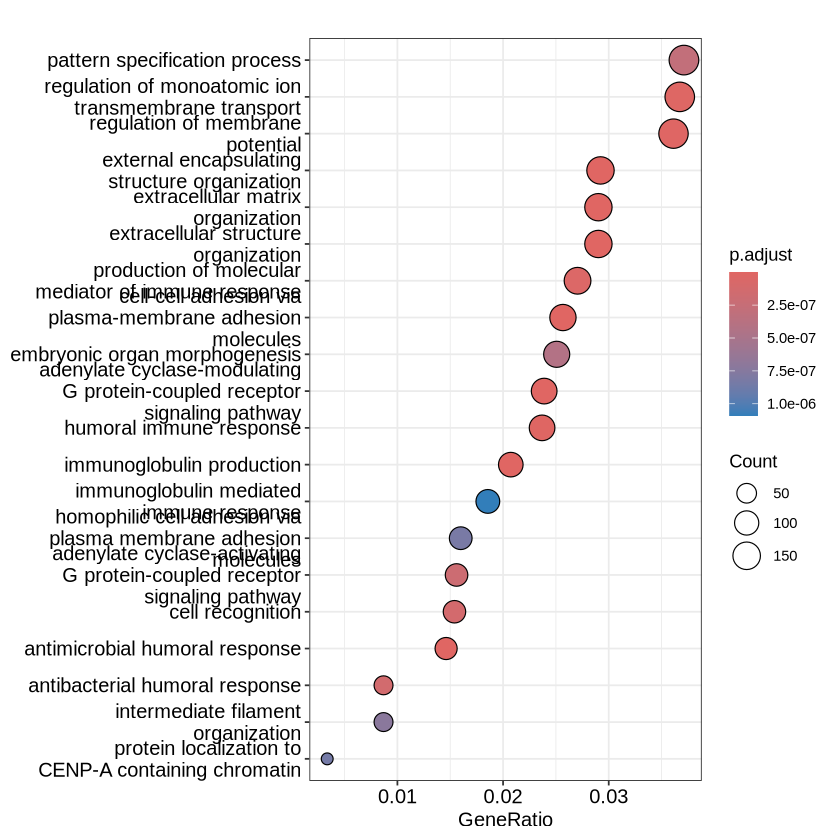

In [18]:
dotplot(
  ego,
  showCategory = 20
)

In [19]:
ggsave(
"figures/GO_enrichment_TCGA_LUAD.png",
width = 8,
height = 6,
dpi = 300
)

In [20]:
kegg <- enrichKEGG(
  gene = gene_ids$ENTREZID,
  organism = "hsa",
  pvalueCutoff = 0.05
)

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...



In [21]:
kegg_results <- as.data.frame(kegg)

head(kegg_results)

,category,subcategory,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
hsa04080,Environmental Information Processing,Signaling molecules and interaction,hsa04080,Neuroactive ligand-receptor interaction,194/2445,371/9422,2.210022e-28,7.735076e-26,6.374168e-26,1901/79924/1910/10203/154/84634/7433/59350/10316/10874/5031/1138/6754/2900/283869/728/2902/2358/1128/153/5028/2890/8698/51083/7425/5645/5646/796/1143/387129/5745/8001/117/1906/5739/9002/5734/2690/2556/3640/2357/1135/5644/148/55584/90226/1081/2859/2906/2147/7253/3953/9934/183/2898/554/3352/2847/2894/553/187/7442/1140/4543/1129/797/8973/2642/2914/3972/79957/55879/6751/6915/6750/8862/146/4985/186/255061/7349/3814/5023/185/4923/7432/2150/10886/4160/1511/53637/122042/2913/5368/130576/117579/2695/2566/1268/2567/3973/2570/8811/7068/3357/1907/100506013/2558/1908/5026/9568/2569/2831/4161/2568/5020/4922/6755/3362/22953/5030/1144/2563/9127/1392/7252/2901/6866/3827/1325/5618/2798/799/4829/84109/222642/150/1137/1146/2893/51052/399967/2837/200959/5746/4986/116444/3358/9248/5024/8484/399968/2151/1134/4988/2564/2891/1141/1269/5737/1132/57152/134/84539/2797/2905/2641/5173/2557/2903/3375/2492/2689/10911/886/2862/11255/9340/2834/4889/56923/7201/23620/4158/114131/3060/2560/887/134864/2895/4887/551/5741/3350,194
hsa04082,NA,NA,hsa04082,Neuroactive ligand signaling,96/2445,199/9422,7.587634e-12,1.327836e-09,1.094217e-09,6532/154/3359/5031/196883/2776/2900/2792/181/2902/1128/153/5028/2890/2786/63910/1143/170572/6505/8001/2556/6540/148/2906/2784/9934/6531/6538/43/2898/2791/3352/115/1129/8973/6512/2914/55879/146/4985/1103/255061/5582/2793/5023/114/4160/2788/2913/5368/2566/2567/6572/2570/9177/3357/2558/5026/9568/2569/2568/6539/3362/22953/5030/2563/9127/2901/6866/64805/150/1137/2893/200959/4986/116444/3358/5024/2785/6571/4988/2564/2891/1141/51764/1132/134/2905/5173/2557/2903/6511/11255/60482/2560/3350,96
hsa05322,Human Diseases,Immune disease,hsa05322,Systemic lupus erythematosus,74/2445,143/9422,3.005527e-11,3.506448e-09,2.889524e-09,3017/8345/8329/8344/8339/8343/8357/3012/8367/8356/8358/8969/440689/8341/3014/8352/8348/8365/8347/8331/8355/8370/2215/8362/712/8294/8970/713/8364/8332/8366/8360/85236/85235/8340/8342/8338/8968/8353/8354/8335/2214/8350/8346/317772/8363/730/8359/8334/1511/732/3018/8336/714/733/8349/3122/729/3113/653604/3111/8337/3127/723790/126961/3458/554313/8368/2903/8361/8290/255626/158983/3013,74
hsa04382,NA,NA,hsa04382,Cornified envelope formation,100/2445,217/9422,8.028621e-11,7.025044e-09,5.789058e-09,26154/1308/3868/7122/5522/3887/144501/9074/29943/7051/84283/6274/11187/3853/9071/1294/6768/6273/79852/1832/9069/3889/6699/338785/51702/59344/1829/3713/1365/3854/3866/3034/51208/1364/54474/3856/151516/28227/23254/9333/3691/3875/6703/3850/23562/9080/3872/23581/3861/196374/6785/6278/3892/9119/6707/9075/140576/6283/1830/3880/147409/286887/342574/1286/6276/1285/5317/6698/3848/3914/3851/5046/5318/5010/6275/6705/3882/25984/140807/8689/390792/319101/3859/338324/6700/1823/3885/125115/3884/126637/6280/100132463/1828/3881/149461/204219/3857/192666/6704/8687,100
hsa04081,NA,NA,hsa04081,Hormone signaling,99/2445,219/9422,3.780914e-10,2.646640e-08,2.180990e-08,10268/10266/154/7433/4881/196883/6754/2776/5593/2792/11069/153/2786/796/5745/2852/2690/10267/148/90226/7066/1734/1081/5744/4883/7253/2784/3953/5295/183/2791/554/2847/115/553/5592/797/2642/3972/6751/2984/6750/146/4985/186/341208/2793/7349/185/4093/7432/114/4160/2788/5368/2695/3973/7068/4161/5020/268/6755/1392/7252/5618/2798/799/150/57817/5296/3690/51052/4986/2785/4842/4988/51764/84539/2797/2641/1733/5173/4880/3375/2492/2689/886/2862/2520/2834/2980/4879/7201/4158/114131/3060/887/551/5741,99
hsa05034,Human Diseases,Substance dependence,hsa05034,Alcoholism,87/2445,191/9422,2.799358e-09,1.632959e-07,1.345656e-07,3017/8345/8329/8344/2792/2902/8339/2786/8343/8357/3012/8367/8356/8358/8969/148327/440689/2354/8341/3014/8352/8348/8365/8347/8331/8355/8370/2906/2784/836

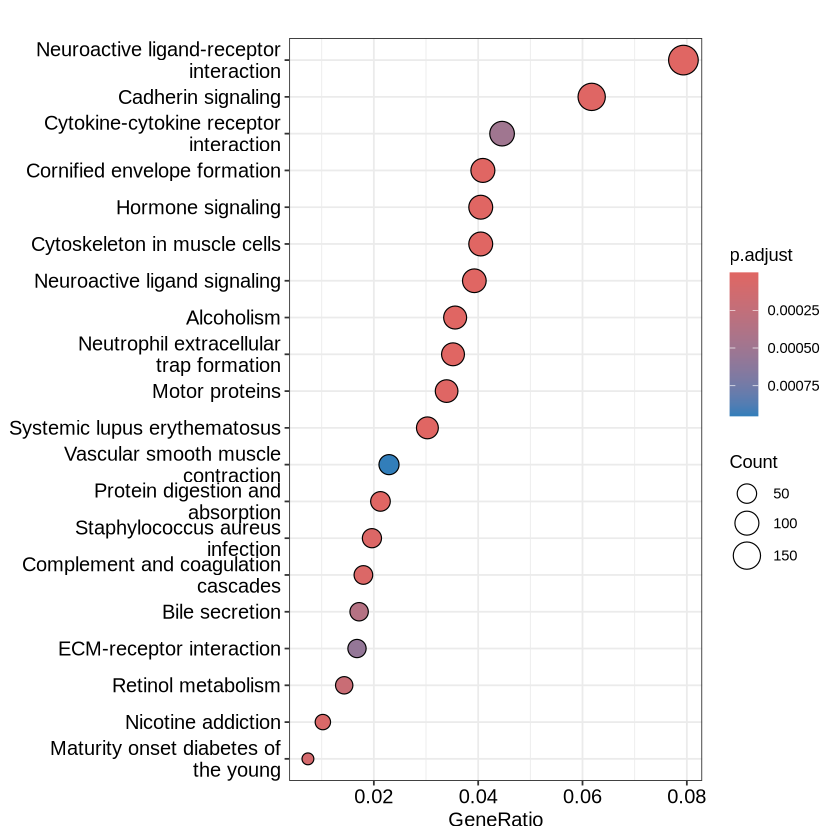

In [22]:
dotplot(
  kegg,
  showCategory = 20
)

In [23]:
ggsave(
"figures/KEGG_pathway_TCGA_LUAD.png",
width = 8,
height = 6,
dpi = 300
)

In [24]:
library(ggplot2)

deg <- genes

deg$Significance <- "Not Significant"

deg$Significance[
  deg$padj < 0.05 & deg$log2FoldChange > 1
] <- "Upregulated"

deg$Significance[
  deg$padj < 0.05 & deg$log2FoldChange < -1
] <- "Downregulated"

head(deg)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,Significance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000147689.16,6257.3020,6.791700,0.2369153,28.66720,9.785412e-181,4.296774e-176,FAM83A,Upregulated
ENSG00000183010.17,3613.0537,3.687783,0.1328495,27.75910,1.353073e-169,2.970671e-165,PYCR1,Upregulated
ENSG00000165312.6,1098.8338,-2.120458,0.0813114,-26.07824,6.437082e-150,9.421742e-146,OTUD1,Downregulated
ENSG00000272620.2,2784.3456,6.305807,0.2572528,24.51211,1.097382e-132,1.204652e-128,AFAP1-AS1,Upregulated
ENSG00000116016.14,26990.0058,-2.723979,0.1113997,-24.45230,4.757257e-132,4.177823e-128,EPAS1,Downregulated
ENSG00000135604.10,805.3661,-3.067332,0.1258437,-24.37414,3.216347e-131,2.353830e-127,STX11,Downregulated


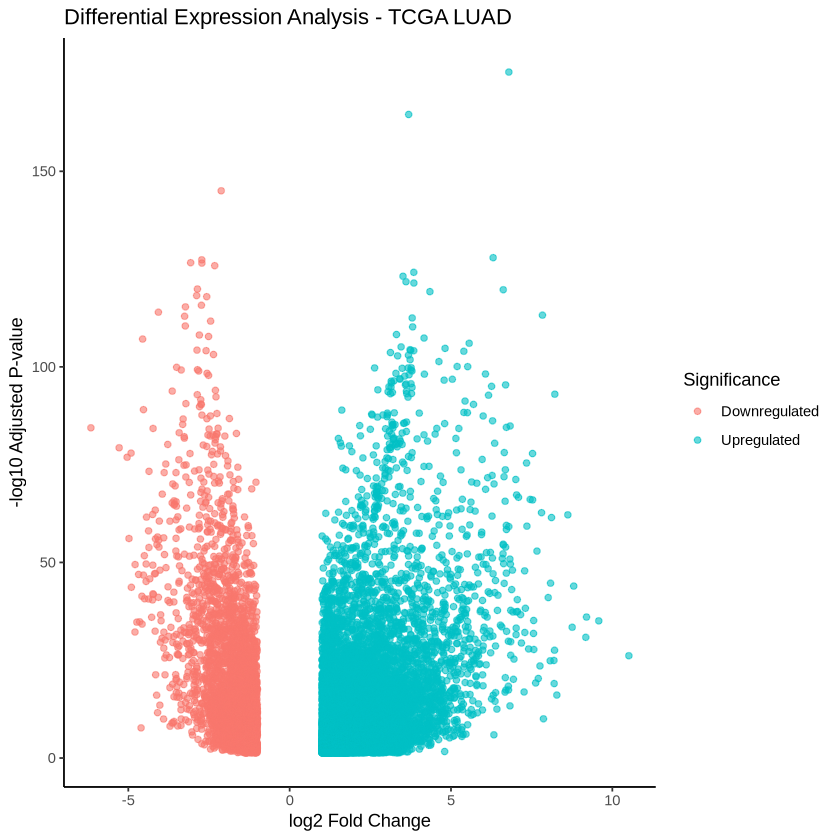

In [25]:
volcano_plot <- ggplot(
  deg,
  aes(
    x = log2FoldChange,
    y = -log10(padj),
    color = Significance
  )
) +
  geom_point(alpha = 0.6) +
  theme_classic() +
  labs(
    title = "Differential Expression Analysis - TCGA LUAD",
    x = "log2 Fold Change",
    y = "-log10 Adjusted P-value"
  )

volcano_plot

In [26]:
ggsave(
"figures/Volcano_plot_TCGA_LUAD.png",
volcano_plot,
width = 8,
height = 6,
dpi = 300
)

In [27]:
top_genes <- deg[
  deg$padj < 0.05 &
  abs(deg$log2FoldChange) > 1,
]

top_genes <- top_genes[
  order(top_genes$padj),
]

head(top_genes, 20)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,Significance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000147689.16,6257.30195,6.791700,0.23691532,28.66720,9.785412e-181,4.296774e-176,FAM83A,Upregulated
ENSG00000183010.17,3613.05367,3.687783,0.13284950,27.75910,1.353073e-169,2.970671e-165,PYCR1,Upregulated
ENSG00000165312.6,1098.83383,-2.120458,0.08131140,-26.07824,6.437082e-150,9.421742e-146,OTUD1,Downregulated
ENSG00000272620.2,2784.34558,6.305807,0.25725276,24.51211,1.097382e-132,1.204652e-128,AFAP1-AS1,Upregulated
ENSG00000116016.14,26990.00583,-2.723979,0.11139974,-24.45230,4.757257e-132,4.177823e-128,EPAS1,Downregulated
ENSG00000135604.10,805.36607,-3.067332,0.12584369,-24.37414,3.216347e-131,2.353830e-127,STX11,Downregulated
ENSG00000235387.5,65.11262,-2.720430,0.11168633,-24.35777,4.796424e-131,3.008728e-127,SPAAR,Downregulated
ENSG00000261371.6,11808.36550,-2.321941,0.09558978,-24.29068,2.459398e-130,1.349902e-126,PECAM1,Downregulated
ENSG00000175832.13,1973.14047,3.846793,0.15945450,24.12470,1.376393e-128,6.715267e-125,ETV4,Upregulated


In [28]:
write.csv(
  top_genes,
  "results/Top_candidate_biomarkers_TCGA_LUAD.csv",
  row.names = FALSE
)

In [34]:
library(data.table)

# Select top 20 significant genes
top20_genes <- head(
  genes[order(padj)],
  20
)

# Save table
fwrite(
  top20_genes,
  "results/Top20_DEG_Biomarkers_TCGA_LUAD.csv"
)

In [31]:
ls()

[1] "deg"           "ego"           "ego_results"   "gene_ids"     
 [5] "gene_symbols"  "genes"         "kegg"          "kegg_category"
 [9] "kegg_results"  "top_genes"     "volcano_plot"

In [32]:
library(data.table)

# Select top 20 significant genes
top20_genes <- head(
  genes[order(padj)],
  20
)

# Save table
fwrite(
  top20_genes,
  "results/Top20_DEG_Biomarkers_TCGA_LUAD.csv"
)

In [33]:
# Save Top 20 candidate biomarkers table
write.csv(
  top_genes,
  "results/Top_20_candidate_genes_TCGA_LUAD.csv",
  row.names = FALSE
)